In [88]:
import pandas as pd
import numpy as np
import random as rnd
import seaborn as sns
import matplotlib.pyplot as plt
import regex as re

In [89]:
df = pd.read_csv('laptop_price.csv',encoding='latin1')

In [90]:
df.head()

,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros
0,1,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,1339.69
1,2,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,898.94
2,3,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,575.00
3,4,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,2537.45
4,5,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,1803.60


In [91]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   laptop_ID         1303 non-null   int64  
 1   Company           1303 non-null   object 
 2   Product           1303 non-null   object 
 3   TypeName          1303 non-null   object 
 4   Inches            1303 non-null   float64
 5   ScreenResolution  1303 non-null   object 
 6   Cpu               1303 non-null   object 
 7   Ram               1303 non-null   object 
 8   Memory            1303 non-null   object 
 9   Gpu               1303 non-null   object 
 10  OpSys             1303 non-null   object 
 11  Weight            1303 non-null   object 
 12  Price_euros       1303 non-null   float64
dtypes: float64(2), int64(1), object(10)
memory usage: 132.5+ KB


In [92]:
#df.describe(include='all')
df.describe()

,laptop_ID,Inches,Price_euros
count,1303.000000,1303.000000,1303.000000
mean,660.155794,15.017191,1123.686992
std,381.172104,1.426304,699.009043
min,1.000000,10.100000,174.000000
25%,331.500000,14.000000,599.000000
50%,659.000000,15.600000,977.000000
75%,990.500000,15.600000,1487.880000
max,1320.000000,18.400000,6099.000000


Nos damos cuenta de:
- **laptop_ID**: No cuadra con el indice del dataframe, lo normal seria que laptop_ID = indice + 1. Sin embargo, esta columna no sera necesaria en el análisis.
- **Inches(Pulgadas)**: Esta en el Intervalo de 10.1 a 18.4 y de que la media es 15 pulgadas, ya que todas las filas utilizan las mismas unidades, solo mantendremos el valor numerico indicando las unidades en el nombre de la columna.
- **Price_euros(Precio en Euros)**: El precio esta en el intervalo de 174 a 6099 y de que la media es 1123.68, todo los precios estan en euros, mas adelante seran cambiados a Soles (Perú).
- Las columnas **ScreenResolution**, **Cpu**, **Gpu** continen datos relevantes, a estas columnas le aplicaremos splitting.

## **Limpieza de Datos**

### **Objetivos:**

- Traduciremos el nombre de las columnas para un mejor entendimiento de los datos.
- Verificaremos la existencia de filas duplicadas.
- Se eliminara la columna `laptop_ID`, ya que no es relevante para el análisis.
- Haremos splitting a la columna `ResolucionPantalla` para extraer las columnas `Resolucion` y `TipoPantalla`.
- Haremos splitting a la columna `PantallaTactil` para extraer las columnas `PantallaTactil` y `TipoPantalla`.
- Haremos splitting a la columna `Procesador` para extraer las columnas `Marca_procesador` y `Proc_freq(GHz)` (float).
- Haremos splitting a la columna `Almacenamiento` para extraer las columnas `Almacenamiento_1(GB)`, `Almacenamiento_1_tipo`, `Almacenamiento_2_(GB)`, `Almacenamiento_2_tipo`.
- Haremos el cambio de moneda a la columna `Precio` de euros a soles (Perú).
- Haremos el cambio de las columnas `RAM`, `Peso` a `RAM(GB)` y `Peso(kg)` respectivamente para tener valores numericos.

Revisamos las columnas

In [93]:
df.columns

Index(['laptop_ID', 'Company', 'Product', 'TypeName', 'Inches',
       'ScreenResolution', 'Cpu', 'Ram', 'Memory', 'Gpu', 'OpSys', 'Weight',
       'Price_euros'],
      dtype='object')

### Traducción de columnas

In [94]:
nombres_espanol = {
    'laptop_ID': 'ID_laptop',
    'Company': 'Marca',
    'Product': 'Producto',
    'TypeName': 'Tipo',
    'Inches': 'Pulgadas',
    'ScreenResolution': 'ResolucionPantalla',
    'Cpu': 'Procesador',
    'Ram': 'RAM',
    'Memory': 'Almacenamiento',
    'Gpu': 'GPU',
    'OpSys': 'SistemaOperativo',
    'Weight': 'Peso',
    'Price_euros': 'Precio(S/)'
}
df.rename(columns=nombres_espanol, inplace=True)
df.columns

Index(['ID_laptop', 'Marca', 'Producto', 'Tipo', 'Pulgadas',
       'ResolucionPantalla', 'Procesador', 'RAM', 'Almacenamiento', 'GPU',
       'SistemaOperativo', 'Peso', 'Precio(S/)'],
      dtype='object')

### Verificación de duplicados

In [95]:
df[df.duplicated()]

,ID_laptop,Marca,Producto,Tipo,Pulgadas,ResolucionPantalla,Procesador,RAM,Almacenamiento,GPU,SistemaOperativo,Peso,Precio(S/)


### Colummna `ID_laptop`

In [96]:
df['ID_laptop']

0          1
1          2
2          3
3          4
4          5
        ... 
1298    1316
1299    1317
1300    1318
1301    1319
1302    1320
Name: ID_laptop, Length: 1303, dtype: int64

Procederemos a eliminar la columna `ID_laptop`, debido a la poca relevancia 

In [97]:
df=df.drop('ID_laptop', axis=1)

### Columna `Precio(S/.)`

Utilizando el tipo de cambio: 1 € = 4.16 S/. (9/02/2024)

In [98]:
tasa_cambio = 4.16
df['Precio(S/)'] = df['Precio(S/)'] * tasa_cambio
df['Precio(S/)'] = df['Precio(S/)'].round(2)

### Columna `ResolucionPantalla`

In [99]:
df['ResolucionPantalla']

0               IPS Panel Retina Display 2560x1600
1                                         1440x900
2                                Full HD 1920x1080
3               IPS Panel Retina Display 2880x1800
4               IPS Panel Retina Display 2560x1600
                           ...                    
1298     IPS Panel Full HD / Touchscreen 1920x1080
1299    IPS Panel Quad HD+ / Touchscreen 3200x1800
1300                                      1366x768
1301                                      1366x768
1302                                      1366x768
Name: ResolucionPantalla, Length: 1303, dtype: object

Creammos la columna `Resolucion` a partir de la columna  `ResolucionPantalla`.

In [100]:
df['Resolucion'] = df['ResolucionPantalla'].str.extract(r'(\d+x\d+)')
df['Resolucion']

0       2560x1600
1        1440x900
2       1920x1080
3       2880x1800
4       2560x1600
          ...    
1298    1920x1080
1299    3200x1800
1300     1366x768
1301     1366x768
1302     1366x768
Name: Resolucion, Length: 1303, dtype: object

Creammos la columna `TipoPantalla` a partir de la columna  `ResolucionPantalla`, y modificamos los valores.

In [101]:
df['TipoPantalla'] = df['ResolucionPantalla'].replace(r'(\d+x\d+)','',regex=True)
df['TipoPantalla']

0               IPS Panel Retina Display 
1                                        
2                                Full HD 
3               IPS Panel Retina Display 
4               IPS Panel Retina Display 
                      ...                
1298     IPS Panel Full HD / Touchscreen 
1299    IPS Panel Quad HD+ / Touchscreen 
1300                                     
1301                                     
1302                                     
Name: TipoPantalla, Length: 1303, dtype: object

In [102]:
df['TipoPantalla'] = df['TipoPantalla'].replace(r'(Full HD|Quad HD|Quad HD|\+|/|4K Ultra HD)','',regex=True)

In [103]:
df['TipoPantalla']

0       IPS Panel Retina Display 
1                                
2                                
3       IPS Panel Retina Display 
4       IPS Panel Retina Display 
                  ...            
1298     IPS Panel   Touchscreen 
1299     IPS Panel   Touchscreen 
1300                             
1301                             
1302                             
Name: TipoPantalla, Length: 1303, dtype: object

Creammos la columna `PantallaTactil` a partir de la columna  `TipoPantalla`, y modificamos los valores.

In [104]:
df['PantallaTactil'] = df['TipoPantalla'].str.extract(r'(Touchscreen)')
df['TipoPantalla'] = df['TipoPantalla'].replace(r'(Touchscreen)','',regex=True)

In [105]:
df['PantallaTactil']

0               NaN
1               NaN
2               NaN
3               NaN
4               NaN
           ...     
1298    Touchscreen
1299    Touchscreen
1300            NaN
1301            NaN
1302            NaN
Name: PantallaTactil, Length: 1303, dtype: object

In [106]:
df['PantallaTactil'] = df['PantallaTactil'].replace('Touchscreen',1)
df['PantallaTactil'] = df['PantallaTactil'].replace(np.nan,0)

In [107]:
df['PantallaTactil'].value_counts()

PantallaTactil
0.0    1111
1.0     192
Name: count, dtype: int64

Singularizamos la columna `TipoPantalla` 

In [108]:
df['TipoPantalla'].value_counts()

TipoPantalla
                             549
                             314
IPS Panel                    265
                              75
IPS Panel                     72
IPS Panel Retina Display      17
IPS Panel                     11
Name: count, dtype: int64

In [109]:
df['TipoPantalla']=df['TipoPantalla'].replace(r' ','',regex=True)
df['TipoPantalla'].value_counts()

TipoPantalla
                         938
IPSPanel                 348
IPSPanelRetinaDisplay     17
Name: count, dtype: int64

In [110]:
df['TipoPantalla'] = df['TipoPantalla'].replace(r'^\s*$', np.nan, regex=True)
df['TipoPantalla'].value_counts()

TipoPantalla
IPSPanel                 348
IPSPanelRetinaDisplay     17
Name: count, dtype: int64

In [111]:
df.head()

,Marca,Producto,Tipo,Pulgadas,ResolucionPantalla,Procesador,RAM,Almacenamiento,GPU,SistemaOperativo,Peso,Precio(S/),Resolucion,TipoPantalla,PantallaTactil
0,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,5573.11,2560x1600,IPSPanelRetinaDisplay,0.0
1,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,3739.59,1440x900,NaN,0.0
2,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,2392.00,1920x1080,NaN,0.0
3,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,10555.79,2880x1800,IPSPanelRetinaDisplay,0.0
4,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,7502.98,2560x1600,IPSPanelRetinaDisplay,0.0


Ya que hicimos "splitting" a la columna `ResolucionPantalla` procederemos eliminar la columna.

In [112]:
df = df.drop('ResolucionPantalla', axis=1)

In [113]:
df.head()

,Marca,Producto,Tipo,Pulgadas,Procesador,RAM,Almacenamiento,GPU,SistemaOperativo,Peso,Precio(S/),Resolucion,TipoPantalla,PantallaTactil
0,Apple,MacBook Pro,Ultrabook,13.3,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,5573.11,2560x1600,IPSPanelRetinaDisplay,0.0
1,Apple,Macbook Air,Ultrabook,13.3,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,3739.59,1440x900,NaN,0.0
2,HP,250 G6,Notebook,15.6,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,2392.00,1920x1080,NaN,0.0
3,Apple,MacBook Pro,Ultrabook,15.4,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,10555.79,2880x1800,IPSPanelRetinaDisplay,0.0
4,Apple,MacBook Pro,Ultrabook,13.3,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,7502.98,2560x1600,IPSPanelRetinaDisplay,0.0


Verificamos las columnas `Resolucion`, `TipoPantalla` y `PantallaTactil`

In [114]:
df['Resolucion'].value_counts()

Resolucion
1920x1080    841
1366x768     308
3840x2160     43
3200x1800     27
2560x1440     23
1600x900      23
2560x1600      6
2304x1440      6
2256x1504      6
1920x1200      5
1440x900       4
2880x1800      4
2400x1600      4
2160x1440      2
2736x1824      1
Name: count, dtype: int64

In [115]:
df['TipoPantalla'].value_counts()

TipoPantalla
IPSPanel                 348
IPSPanelRetinaDisplay     17
Name: count, dtype: int64

In [116]:
df['PantallaTactil'].value_counts()

PantallaTactil
0.0    1111
1.0     192
Name: count, dtype: int64

### Columna `Procesador`

In [117]:
df['Procesador']

0                       Intel Core i5 2.3GHz
1                       Intel Core i5 1.8GHz
2                 Intel Core i5 7200U 2.5GHz
3                       Intel Core i7 2.7GHz
4                       Intel Core i5 3.1GHz
                        ...                 
1298              Intel Core i7 6500U 2.5GHz
1299              Intel Core i7 6500U 2.5GHz
1300    Intel Celeron Dual Core N3050 1.6GHz
1301              Intel Core i7 6500U 2.5GHz
1302    Intel Celeron Dual Core N3050 1.6GHz
Name: Procesador, Length: 1303, dtype: object

Creammos la columna `Proc_freq(GHz)` a partir de la columna  `Procesador` para que contenga valores numericos.

In [118]:
df['Proc_freq'] = df['Procesador'].str.extract(r'(\d+(?:\.\d+)?GHz)') 

In [119]:
df['Proc_freq'].value_counts()

Proc_freq
2.5GHz     290
2.7GHz     165
2.8GHz     165
1.6GHz     133
2.3GHz      86
1.8GHz      78
2.6GHz      76
2GHz        67
1.1GHz      53
2.4GHz      52
2.9GHz      21
3GHz        19
2.0GHz      19
1.2GHz      15
1.44GHz     12
2.2GHz      11
1.5GHz      10
1.3GHz       6
3.6GHz       5
0.9GHz       4
3.1GHz       3
2.1GHz       3
2.50GHz      3
1.9GHz       2
1.60GHz      1
3.2GHz       1
1.0GHz       1
1.92GHz      1
2.70GHz      1
Name: count, dtype: int64

In [120]:
df['Proc_freq'] = df['Proc_freq'].str.replace('GHz', '')
df.rename(columns={'Proc_freq': 'Proc_freq(GHz)'}, inplace=True)

In [121]:
df['Proc_freq(GHz)'] = df['Proc_freq(GHz)'].astype(float)

In [122]:
df['Proc_freq(GHz)'].value_counts()

Proc_freq(GHz)
2.50    293
2.70    166
2.80    165
1.60    134
2.30     86
2.00     86
1.80     78
2.60     76
1.10     53
2.40     52
2.90     21
3.00     19
1.20     15
1.44     12
2.20     11
1.50     10
1.30      6
3.60      5
0.90      4
3.10      3
2.10      3
1.90      2
3.20      1
1.00      1
1.92      1
Name: count, dtype: int64

In [123]:
df['Procesador']= df['Procesador'].str.replace(r'(\d+(?:\.\d+)?GHz)', '', regex=True)

In [124]:
df.head()

,Marca,Producto,Tipo,Pulgadas,Procesador,RAM,Almacenamiento,GPU,SistemaOperativo,Peso,Precio(S/),Resolucion,TipoPantalla,PantallaTactil,Proc_freq(GHz)
0,Apple,MacBook Pro,Ultrabook,13.3,Intel Core i5,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,5573.11,2560x1600,IPSPanelRetinaDisplay,0.0,2.3
1,Apple,Macbook Air,Ultrabook,13.3,Intel Core i5,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,3739.59,1440x900,NaN,0.0,1.8
2,HP,250 G6,Notebook,15.6,Intel Core i5 7200U,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,2392.00,1920x1080,NaN,0.0,2.5
3,Apple,MacBook Pro,Ultrabook,15.4,Intel Core i7,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,10555.79,2880x1800,IPSPanelRetinaDisplay,0.0,2.7
4,Apple,MacBook Pro,Ultrabook,13.3,Intel Core i5,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,7502.98,2560x1600,IPSPanelRetinaDisplay,0.0,3.1


### Columna `RAM`

Extraemos "GB" de cada valor de la columna,renombramos la columna a "RAM(GB)"  y convertimos a (int)

In [125]:
df['RAM'] = df['RAM'].str.replace('GB', '')

In [126]:
df.rename(columns={'RAM': 'RAM(GB)'}, inplace=True)

In [127]:
df['RAM(GB)'] = df['RAM(GB)'].astype(int)

In [128]:
df.head()

,Marca,Producto,Tipo,Pulgadas,Procesador,RAM(GB),Almacenamiento,GPU,SistemaOperativo,Peso,Precio(S/),Resolucion,TipoPantalla,PantallaTactil,Proc_freq(GHz)
0,Apple,MacBook Pro,Ultrabook,13.3,Intel Core i5,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,5573.11,2560x1600,IPSPanelRetinaDisplay,0.0,2.3
1,Apple,Macbook Air,Ultrabook,13.3,Intel Core i5,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,3739.59,1440x900,NaN,0.0,1.8
2,HP,250 G6,Notebook,15.6,Intel Core i5 7200U,8,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,2392.00,1920x1080,NaN,0.0,2.5
3,Apple,MacBook Pro,Ultrabook,15.4,Intel Core i7,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,10555.79,2880x1800,IPSPanelRetinaDisplay,0.0,2.7
4,Apple,MacBook Pro,Ultrabook,13.3,Intel Core i5,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,7502.98,2560x1600,IPSPanelRetinaDisplay,0.0,3.1


### Columna `Almacenamiento`

Crearemos las columnas `Almacenamiento_1(GB)`, `Almacenamiento_1_tipo`,	`Almacenamiento_2(GB)`,	`Almacenamiento_2_tipo`.

In [129]:
df['Almacenamiento']

0                 128GB SSD
1       128GB Flash Storage
2                 256GB SSD
3                 512GB SSD
4                 256GB SSD
               ...         
1298              128GB SSD
1299              512GB SSD
1300     64GB Flash Storage
1301                1TB HDD
1302              500GB HDD
Name: Almacenamiento, Length: 1303, dtype: object

In [130]:
df['Almacenamiento'].value_counts()

Almacenamiento
256GB SSD                        412
1TB HDD                          223
500GB HDD                        132
512GB SSD                        118
128GB SSD +  1TB HDD              94
128GB SSD                         76
256GB SSD +  1TB HDD              73
32GB Flash Storage                38
2TB HDD                           16
64GB Flash Storage                15
512GB SSD +  1TB HDD              14
1TB SSD                           14
256GB SSD +  2TB HDD              10
1.0TB Hybrid                       9
256GB Flash Storage                8
16GB Flash Storage                 7
32GB SSD                           6
180GB SSD                          5
128GB Flash Storage                4
512GB SSD +  2TB HDD               3
16GB SSD                           3
512GB Flash Storage                2
1TB SSD +  1TB HDD                 2
256GB SSD +  500GB HDD             2
128GB SSD +  2TB HDD               2
256GB SSD +  256GB SSD             2
512GB SSD +  256GB SSD 

In [131]:
df['Almacenamiento_1']=df['Almacenamiento']

In [132]:
df['Almacenamiento_1']=df['Almacenamiento_1'].str.replace('1.0TB','1TB', regex=True)
df['Almacenamiento_1']=df['Almacenamiento_1'].str.replace('1TB','1000GB')
df['Almacenamiento_1']=df['Almacenamiento_1'].str.replace('2TB','2000GB')
df['Almacenamiento_1']=df['Almacenamiento_1'].str.replace('GB','')
df['Almacenamiento_1'].value_counts()

Almacenamiento_1
256 SSD                         412
1000 HDD                        224
500 HDD                         132
512 SSD                         118
128 SSD +  1000 HDD              94
128 SSD                          76
256 SSD +  1000 HDD              73
32 Flash Storage                 38
2000 HDD                         16
64 Flash Storage                 15
512 SSD +  1000 HDD              14
1000 SSD                         14
256 SSD +  2000 HDD              10
1000 Hybrid                       9
256 Flash Storage                 8
16 Flash Storage                  7
32 SSD                            6
180 SSD                           5
128 Flash Storage                 4
512 SSD +  2000 HDD               3
16 SSD                            3
512 Flash Storage                 2
1000 SSD +  1000 HDD              2
256 SSD +  500 HDD                2
128 SSD +  2000 HDD               2
256 SSD +  256 SSD                2
512 SSD +  256 SSD                1
512 SSD +  

In [133]:
df['Almacenamiento_2']=df['Almacenamiento_1'].str.replace(r' ','')
df['Almacenamiento_2'].value_counts()

Almacenamiento_2
256SSD                    412
1000HDD                   224
500HDD                    132
512SSD                    118
128SSD+1000HDD             94
128SSD                     76
256SSD+1000HDD             73
32FlashStorage             38
2000HDD                    16
64FlashStorage             15
512SSD+1000HDD             14
1000SSD                    14
256SSD+2000HDD             10
1000Hybrid                  9
256FlashStorage             8
16FlashStorage              7
32SSD                       6
180SSD                      5
128FlashStorage             4
512SSD+2000HDD              3
16SSD                       3
512FlashStorage             2
1000SSD+1000HDD             2
256SSD+500HDD               2
128SSD+2000HDD              2
256SSD+256SSD               2
512SSD+256SSD               1
512SSD+512SSD               1
64FlashStorage+1000HDD      1
1000HDD+1000HDD             1
32HDD                       1
64SSD                       1
128HDD                 

Creamos las listas auxiliares  'Almacenamiento_1','Almacenamiento_2', luego procederemos a eliminarlos junto a la columna `Almacenamiento`

In [134]:
Almacenamiento_1=[]
Almacenamiento_2=[]
for i in df['Almacenamiento_2']:
    if len(re.findall(r'\+',i))==1: # DOUBLE DRIVE
        one=re.findall(r'(\w+)',i)
        Almacenamiento_1.append(one[0])
        Almacenamiento_2.append(one[1])
    else: # SINGLE DRIVE
        one=re.findall(r'(\w+)',i)
        Almacenamiento_1.append(one[0])
        Almacenamiento_2.append('NaN')

In [135]:
Almacenamiento_1_gb=[]
Almacenamiento_1_tipo=[]
for i in Almacenamiento_1:
    Almacenamiento_1_tipo.append(re.findall(r'(\D\w+)',i)[0])
    Almacenamiento_1_gb.append(re.findall(r'(\d+)',i)[0])

In [136]:
Almacenamiento_2_gb=[]
Almacenamiento_2_tipo=[]
for i in Almacenamiento_2:
    if i != 'NaN':
        Almacenamiento_2_tipo.append(re.findall(r'(\D\w+)',i)[0])
        Almacenamiento_2_gb.append(re.findall(r'(\d+)',i)[0])
    else:
        Almacenamiento_2_tipo.append('NaN')
        Almacenamiento_2_gb.append(0)

In [137]:
df['Almacenamiento_1(GB)'] = Almacenamiento_1_gb
df['Almacenamiento_1_tipo'] = Almacenamiento_1_tipo
df['Almacenamiento_2(GB)'] = Almacenamiento_2_gb
df['Almacenamiento_2_tipo'] = Almacenamiento_2_tipo

In [138]:
df['Almacenamiento_1(GB)'] = df['Almacenamiento_1(GB)'].astype(float)
df['Almacenamiento_2(GB)'] = df['Almacenamiento_2(GB)'].astype(float)

In [139]:
df.head()

,Marca,Producto,Tipo,Pulgadas,Procesador,RAM(GB),Almacenamiento,GPU,SistemaOperativo,Peso,...,Resolucion,TipoPantalla,PantallaTactil,Proc_freq(GHz),Almacenamiento_1,Almacenamiento_2,Almacenamiento_1(GB),Almacenamiento_1_tipo,Almacenamiento_2(GB),Almacenamiento_2_tipo
0,Apple,MacBook Pro,Ultrabook,13.3,Intel Core i5,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,...,2560x1600,IPSPanelRetinaDisplay,0.0,2.3,128 SSD,128SSD,128.0,SSD,0.0,NaN
1,Apple,Macbook Air,Ultrabook,13.3,Intel Core i5,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,...,1440x900,NaN,0.0,1.8,128 Flash Storage,128FlashStorage,128.0,FlashStorage,0.0,NaN
2,HP,250 G6,Notebook,15.6,Intel Core i5 7200U,8,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,...,1920x1080,NaN,0.0,2.5,256 SSD,256SSD,256.0,SSD,0.0,NaN
3,Apple,MacBook Pro,Ultrabook,15.4,Intel Core i7,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,...,2880x1800,IPSPanelRetinaDisplay,0.0,2.7,512 SSD,512SSD,512.0,SSD,0.0,NaN
4,Apple,MacBook Pro,Ultrabook,13.3,Intel Core i5,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,...,2560x1600,IPSPanelRetinaDisplay,0.0,3.1,256 SSD,256SSD,256.0,SSD,0.0,NaN


Eliminamos las columnas `Almacenamiento_1`, `Almacenamiento_2`, `Almacenamiento`

In [140]:
df=df.drop(['Almacenamiento_1','Almacenamiento_2','Almacenamiento'], axis=1)

In [141]:
df = df.replace({'NaN': np.nan})
df.head()

,Marca,Producto,Tipo,Pulgadas,Procesador,RAM(GB),GPU,SistemaOperativo,Peso,Precio(S/),Resolucion,TipoPantalla,PantallaTactil,Proc_freq(GHz),Almacenamiento_1(GB),Almacenamiento_1_tipo,Almacenamiento_2(GB),Almacenamiento_2_tipo
0,Apple,MacBook Pro,Ultrabook,13.3,Intel Core i5,8,Intel Iris Plus Graphics 640,macOS,1.37kg,5573.11,2560x1600,IPSPanelRetinaDisplay,0.0,2.3,128.0,SSD,0.0,NaN
1,Apple,Macbook Air,Ultrabook,13.3,Intel Core i5,8,Intel HD Graphics 6000,macOS,1.34kg,3739.59,1440x900,NaN,0.0,1.8,128.0,FlashStorage,0.0,NaN
2,HP,250 G6,Notebook,15.6,Intel Core i5 7200U,8,Intel HD Graphics 620,No OS,1.86kg,2392.00,1920x1080,NaN,0.0,2.5,256.0,SSD,0.0,NaN
3,Apple,MacBook Pro,Ultrabook,15.4,Intel Core i7,16,AMD Radeon Pro 455,macOS,1.83kg,10555.79,2880x1800,IPSPanelRetinaDisplay,0.0,2.7,512.0,SSD,0.0,NaN
4,Apple,MacBook Pro,Ultrabook,13.3,Intel Core i5,8,Intel Iris Plus Graphics 650,macOS,1.37kg,7502.98,2560x1600,IPSPanelRetinaDisplay,0.0,3.1,256.0,SSD,0.0,NaN


### Columna `Peso`

In [142]:
df['Peso'].value_counts()

Peso
2.2kg     121
2.1kg      58
2.4kg      44
2.3kg      41
2.5kg      38
         ... 
3.25kg      1
4.7kg       1
1.55kg      1
1.18kg      1
4.0kg       1
Name: count, Length: 179, dtype: int64

Eliminamos los caracteres "kg" y casteamos la columna a (float)

In [143]:
df['Peso'].str.contains('kg').sum()

1303

In [144]:
df['Peso'] = df['Peso'].str.replace('kg','').astype(float)

Renombramos la columna a `Peso(kg)`

In [145]:
df.rename(columns={'Peso': 'Peso(kg)'}, inplace=True)

In [146]:
df.head()

,Marca,Producto,Tipo,Pulgadas,Procesador,RAM(GB),GPU,SistemaOperativo,Peso(kg),Precio(S/),Resolucion,TipoPantalla,PantallaTactil,Proc_freq(GHz),Almacenamiento_1(GB),Almacenamiento_1_tipo,Almacenamiento_2(GB),Almacenamiento_2_tipo
0,Apple,MacBook Pro,Ultrabook,13.3,Intel Core i5,8,Intel Iris Plus Graphics 640,macOS,1.37,5573.11,2560x1600,IPSPanelRetinaDisplay,0.0,2.3,128.0,SSD,0.0,NaN
1,Apple,Macbook Air,Ultrabook,13.3,Intel Core i5,8,Intel HD Graphics 6000,macOS,1.34,3739.59,1440x900,NaN,0.0,1.8,128.0,FlashStorage,0.0,NaN
2,HP,250 G6,Notebook,15.6,Intel Core i5 7200U,8,Intel HD Graphics 620,No OS,1.86,2392.00,1920x1080,NaN,0.0,2.5,256.0,SSD,0.0,NaN
3,Apple,MacBook Pro,Ultrabook,15.4,Intel Core i7,16,AMD Radeon Pro 455,macOS,1.83,10555.79,2880x1800,IPSPanelRetinaDisplay,0.0,2.7,512.0,SSD,0.0,NaN
4,Apple,MacBook Pro,Ultrabook,13.3,Intel Core i5,8,Intel Iris Plus Graphics 650,macOS,1.37,7502.98,2560x1600,IPSPanelRetinaDisplay,0.0,3.1,256.0,SSD,0.0,NaN


### Columna `Marca_procesador`

In [147]:
df['Marca_procesador'] = df['Procesador'].str.extract(r'^(\w+)')
df['Marca_procesador'].value_counts()

Marca_procesador
Intel      1240
AMD          62
Samsung       1
Name: count, dtype: int64

In [148]:
df[df['Marca_procesador']=='Samsung']

,Marca,Producto,Tipo,Pulgadas,Procesador,RAM(GB),GPU,SistemaOperativo,Peso(kg),Precio(S/),Resolucion,TipoPantalla,PantallaTactil,Proc_freq(GHz),Almacenamiento_1(GB),Almacenamiento_1_tipo,Almacenamiento_2(GB),Almacenamiento_2_tipo,Marca_procesador
1191,Samsung,Chromebook Plus,2 in 1 Convertible,12.3,Samsung Cortex A72&A53,4,ARM Mali T860 MP4,Chrome OS,1.15,2741.44,2400x1600,IPSPanel,1.0,2.0,32.0,FlashStorage,0.0,NaN,Samsung


Eliminamos la unica fila con valor 'Samsung' en la columna `Marca_procesador`.

In [149]:
df=df.drop(1191)

In [150]:
#df['Marca_procesador'] = df['gpu'].str.extract(r'^(\w+)')
df['Marca_procesador'].value_counts()

Marca_procesador
Intel    1240
AMD        62
Name: count, dtype: int64

### Columna `GPU`

Creamos la columna `Marca_GPU` a partir de la columna `GPU`.

In [151]:
df['Marca_GPU'] = df['GPU'].str.extract(r'^(\w+)')
df['Marca_GPU'].value_counts()

Marca_GPU
Intel     722
Nvidia    400
AMD       180
Name: count, dtype: int64

In [152]:
df.head()

,Marca,Producto,Tipo,Pulgadas,Procesador,RAM(GB),GPU,SistemaOperativo,Peso(kg),Precio(S/),Resolucion,TipoPantalla,PantallaTactil,Proc_freq(GHz),Almacenamiento_1(GB),Almacenamiento_1_tipo,Almacenamiento_2(GB),Almacenamiento_2_tipo,Marca_procesador,Marca_GPU
0,Apple,MacBook Pro,Ultrabook,13.3,Intel Core i5,8,Intel Iris Plus Graphics 640,macOS,1.37,5573.11,2560x1600,IPSPanelRetinaDisplay,0.0,2.3,128.0,SSD,0.0,NaN,Intel,Intel
1,Apple,Macbook Air,Ultrabook,13.3,Intel Core i5,8,Intel HD Graphics 6000,macOS,1.34,3739.59,1440x900,NaN,0.0,1.8,128.0,FlashStorage,0.0,NaN,Intel,Intel
2,HP,250 G6,Notebook,15.6,Intel Core i5 7200U,8,Intel HD Graphics 620,No OS,1.86,2392.00,1920x1080,NaN,0.0,2.5,256.0,SSD,0.0,NaN,Intel,Intel
3,Apple,MacBook Pro,Ultrabook,15.4,Intel Core i7,16,AMD Radeon Pro 455,macOS,1.83,10555.79,2880x1800,IPSPanelRetinaDisplay,0.0,2.7,512.0,SSD,0.0,NaN,Intel,AMD
4,Apple,MacBook Pro,Ultrabook,13.3,Intel Core i5,8,Intel Iris Plus Graphics 650,macOS,1.37,7502.98,2560x1600,IPSPanelRetinaDisplay,0.0,3.1,256.0,SSD,0.0,NaN,Intel,Intel


Verificamos el tipo de dato de cada columna

In [153]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1302 entries, 0 to 1302
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Marca                  1302 non-null   object 
 1   Producto               1302 non-null   object 
 2   Tipo                   1302 non-null   object 
 3   Pulgadas               1302 non-null   float64
 4   Procesador             1302 non-null   object 
 5   RAM(GB)                1302 non-null   int32  
 6   GPU                    1302 non-null   object 
 7   SistemaOperativo       1302 non-null   object 
 8   Peso(kg)               1302 non-null   float64
 9   Precio(S/)             1302 non-null   float64
 10  Resolucion             1302 non-null   object 
 11  TipoPantalla           364 non-null    object 
 12  PantallaTactil         1302 non-null   float64
 13  Proc_freq(GHz)         1302 non-null   float64
 14  Almacenamiento_1(GB)   1302 non-null   float64
 15  Almacenam

### Guardar datos limpios

In [154]:
df.to_csv('laptop_limpio.csv', index=False)

## **Analisis Exploratorio**

In [155]:
df_1 = pd.read_csv('laptop_limpio.csv')

In [156]:
df_1.head()

,Marca,Producto,Tipo,Pulgadas,Procesador,RAM(GB),GPU,SistemaOperativo,Peso(kg),Precio(S/),Resolucion,TipoPantalla,PantallaTactil,Proc_freq(GHz),Almacenamiento_1(GB),Almacenamiento_1_tipo,Almacenamiento_2(GB),Almacenamiento_2_tipo,Marca_procesador,Marca_GPU
0,Apple,MacBook Pro,Ultrabook,13.3,Intel Core i5,8,Intel Iris Plus Graphics 640,macOS,1.37,5573.11,2560x1600,IPSPanelRetinaDisplay,0.0,2.3,128.0,SSD,0.0,NaN,Intel,Intel
1,Apple,Macbook Air,Ultrabook,13.3,Intel Core i5,8,Intel HD Graphics 6000,macOS,1.34,3739.59,1440x900,NaN,0.0,1.8,128.0,FlashStorage,0.0,NaN,Intel,Intel
2,HP,250 G6,Notebook,15.6,Intel Core i5 7200U,8,Intel HD Graphics 620,No OS,1.86,2392.00,1920x1080,NaN,0.0,2.5,256.0,SSD,0.0,NaN,Intel,Intel
3,Apple,MacBook Pro,Ultrabook,15.4,Intel Core i7,16,AMD Radeon Pro 455,macOS,1.83,10555.79,2880x1800,IPSPanelRetinaDisplay,0.0,2.7,512.0,SSD,0.0,NaN,Intel,AMD
4,Apple,MacBook Pro,Ultrabook,13.3,Intel Core i5,8,Intel Iris Plus Graphics 650,macOS,1.37,7502.98,2560x1600,IPSPanelRetinaDisplay,0.0,3.1,256.0,SSD,0.0,NaN,Intel,Intel


In [157]:
df_Limpio = df_1.copy()

### ¿Qué marca es la más frecuente en el dataframe?

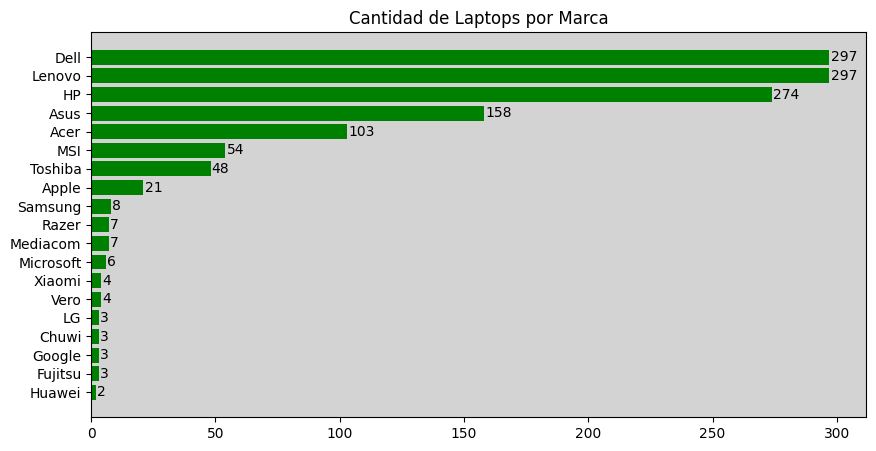

In [158]:
#Grafico utilizando Matplotlib
fig, ax = plt.subplots(figsize=(10, 5))
data = df_Limpio['Marca'].value_counts().sort_values(ascending=True)
ax.barh(data.index, data, color='green')
for i, v in enumerate(data):
    ax.text(v + 0.5, i, str(v), ha='left', va='center')
plt.title('Cantidad de Laptops por Marca')
ax.set_facecolor('lightgrey')
plt.show()

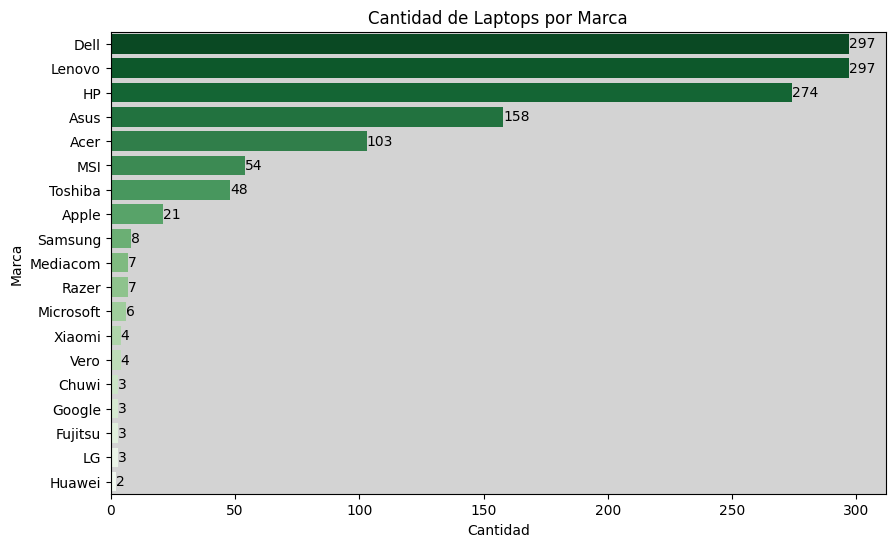

In [159]:
#Grafico utilizando Seaborn y Matplotlib
counts = df_Limpio['Marca'].value_counts().sort_values(ascending=False)
plt.figure(figsize=(10, 6))
ax = sns.barplot(y=counts.index, x=counts,hue=counts.index, palette='Greens_r')
ax.set_title("Cantidad de Laptops por Marca")
ax.set_ylabel("Marca")
ax.set_xlabel("Cantidad")
ax.set_facecolor('lightgrey')
for i, count in enumerate(counts):
    ax.text(count, i, str(count), ha='left', va='center')
plt.show()

La mayoría de las Laptops son de Dell, Lenovo y HP.

### ¿Qué tipo de laptop es la más frecuente en el dataframe?

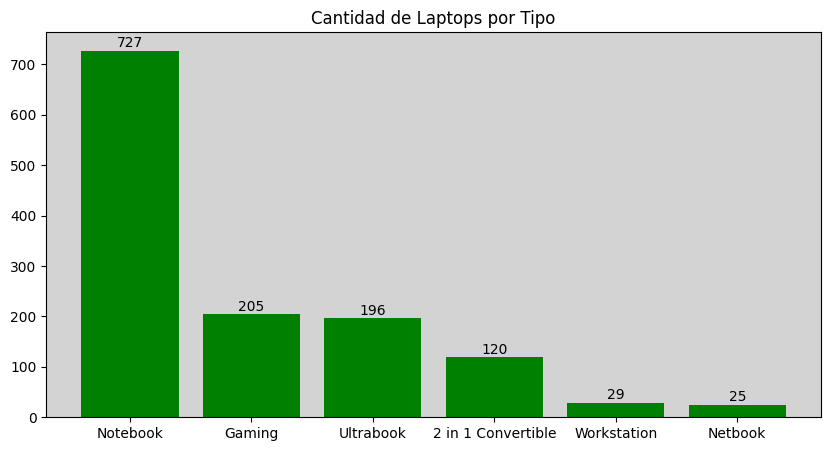

In [160]:
#Grafico utilizando Matplotlib
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(df['Tipo'].value_counts().index, df['Tipo'].value_counts(), color='green')
for i, v in enumerate(df['Tipo'].value_counts()):
    ax.text(i, v + 0.5, str(v), ha='center', va='bottom')
plt.title('Cantidad de Laptops por Tipo')
ax.set_facecolor('lightgrey')
plt.show()

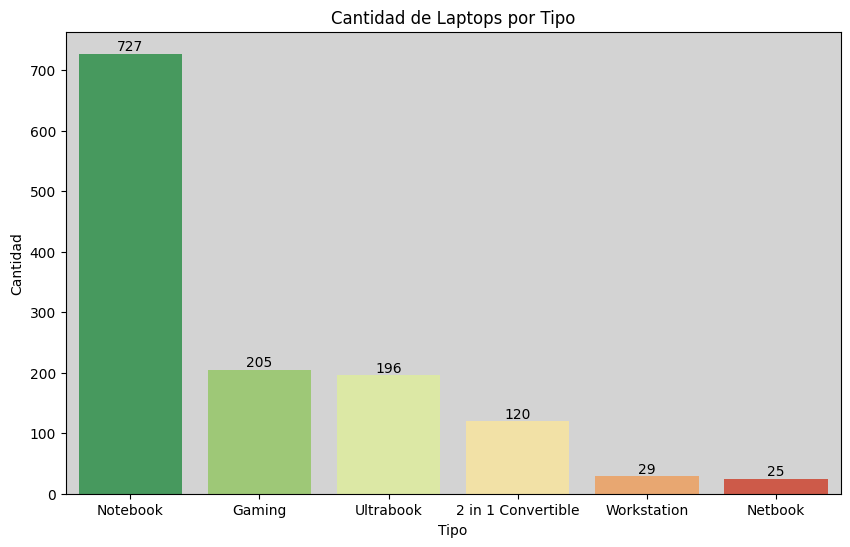

In [161]:
#Grafico utilizando Seaborn y Matplotlib
counts = df_Limpio['Tipo'].value_counts().sort_values(ascending=False)
plt.figure(figsize=(10, 6))
ax = sns.barplot(x=counts.index, y=counts,hue=counts.index, palette='RdYlGn_r')
ax.set_title("Cantidad de Laptops por Tipo")
ax.set_ylabel("Cantidad")
ax.set_xlabel("Tipo")
ax.set_facecolor('lightgrey')
for i, count in enumerate(counts):
    ax.text( i, count, str(count), ha='center', va='bottom')
plt.show()

In [162]:
laptop = counts.index[0]
porcentaje = (counts.iloc[0]/counts.sum()*100).round(2)
print('El tipo de laptop mas popular es la ',laptop, 'con el ',porcentaje,'%')

El tipo de laptop mas popular es la  Notebook con el  55.84 %


### ¿Qué tamaño de laptop es la más frecuente en el dataframe?

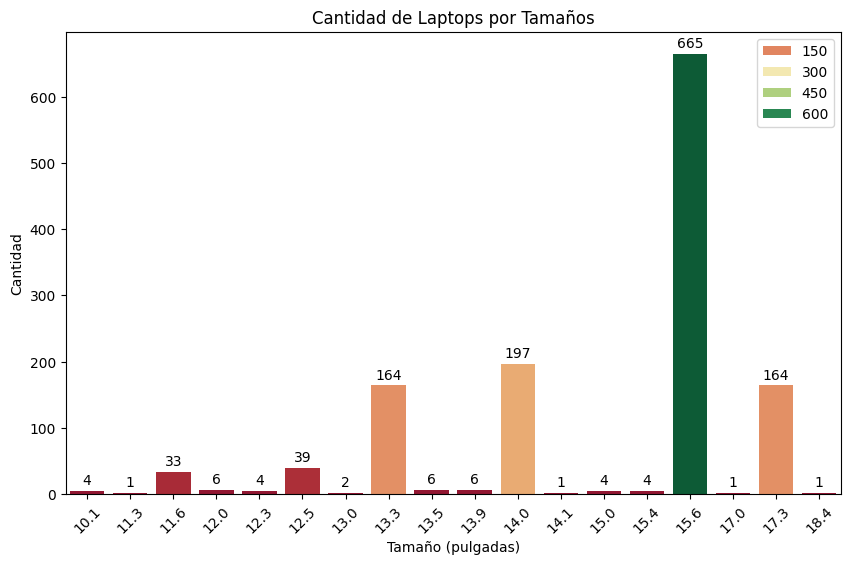

In [163]:
#Grafico utilizando Seaborn y Matplotlib
counts = df_Limpio['Pulgadas'].value_counts().sort_values(ascending=False)
sorted_counts = counts.sort_index()

plt.figure(figsize=(10, 6))
sns.barplot(x=sorted_counts.index, y=sorted_counts.values, hue=sorted_counts.values,palette='RdYlGn')
plt.title("Cantidad de Laptops por Tamaños")
plt.ylabel("Cantidad")
plt.xlabel("Tamaño (pulgadas)")
plt.xticks(rotation=45)

for i, count in enumerate(sorted_counts.values):
    plt.text(i, count + 5, str(count), ha='center', va='bottom')

plt.show()

In [164]:
rank = df_Limpio['Pulgadas'].value_counts().sort_values(ascending=False)
tamanio = rank.index[0]
porcentaje = (rank.iloc[0]/rank.sum()*100).round(2)
print('El tamaño de laptop mas popular es el ',tamanio, ' pulgadas, con el ',porcentaje,'%')

El tamaño de laptop mas popular es el  15.6  pulgadas, con el  51.08 %


#### Observación:
- Vemos que existen tamaños que aparecen en pocas filas lo cual es poco convencional. Por ende solo utilizaremos las laptops con tamaños mas frecuentes (Top 6).

In [165]:
lista_tamanio = df['Pulgadas'].value_counts().index[:6].tolist()
lista_tamanio

[15.6, 14.0, 13.3, 17.3, 12.5, 11.6]

Solo nos quedamos con las filas cuya laptops tienen como medida los 6 tamaños mas frecuentes

In [166]:
df_Limpio = df_Limpio[df_Limpio['Pulgadas'].isin(lista_tamanio)]

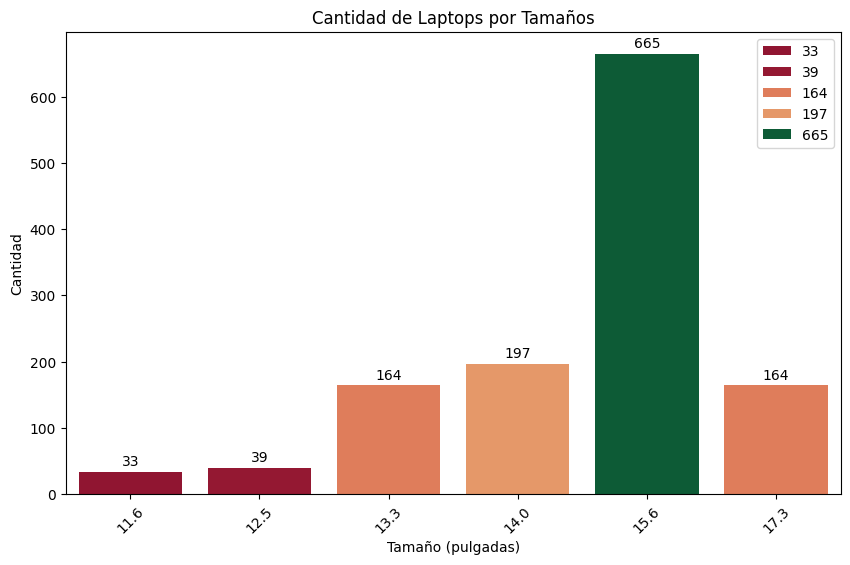

In [167]:
#Grafico utilizando Seaborn y Matplotlib
counts = df_Limpio['Pulgadas'].value_counts().sort_values(ascending=False)
sorted_counts = counts.sort_index()

plt.figure(figsize=(10, 6))
sns.barplot(x=sorted_counts.index, y=sorted_counts.values, hue=sorted_counts.values,palette='RdYlGn')
plt.title("Cantidad de Laptops por Tamaños")
plt.ylabel("Cantidad")
plt.xlabel("Tamaño (pulgadas)")
plt.xticks(rotation=45)

for i, count in enumerate(sorted_counts.values):
    plt.text(i, count + 5, str(count), ha='center', va='bottom')

plt.show()

### Funcion Distribución

Para hallar la distribucion de las columnas de valor numerico

In [168]:
def graficar_distribucion_numerica(df, col, titulo, unidades):
    fig, ax = plt.subplots(2, 1, sharex=True, figsize=(8,5),gridspec_kw={"height_ratios": (.2, .8)})
    ax[0].set_title(titulo,fontsize=18)
    sns.boxplot(x=col, data=df, ax=ax[0])
    ax[0].set(yticks=[])
    sns.histplot(x=col, data=df, ax=ax[1])
    ax[1].set_xlabel(col, fontsize=16)
    plt.axvline(df[col].mean(), color='green', linewidth=2.2, label='Media=' + str(np.round(df[col].mean(),1)) + unidades)
    plt.axvline(df[col].median(), color='red', linewidth=2.2, label='Mediana='+ str(np.round(df[col].median(),1)) + unidades)
    plt.axvline(df[col].mode()[0], color='purple', linewidth=2.2, label='Moda='+ str(df[col].mode()[0]) + unidades)
    plt.legend(bbox_to_anchor=(1, 1.03), ncol=1, fontsize=17, fancybox=True, shadow=True, frameon=True)
    plt.tight_layout()
    plt.show()

In [169]:
df_Limpio.columns

Index(['Marca', 'Producto', 'Tipo', 'Pulgadas', 'Procesador', 'RAM(GB)', 'GPU',
       'SistemaOperativo', 'Peso(kg)', 'Precio(S/)', 'Resolucion',
       'TipoPantalla', 'PantallaTactil', 'Proc_freq(GHz)',
       'Almacenamiento_1(GB)', 'Almacenamiento_1_tipo', 'Almacenamiento_2(GB)',
       'Almacenamiento_2_tipo', 'Marca_procesador', 'Marca_GPU'],
      dtype='object')

### Distribución del Peso en las Laptops

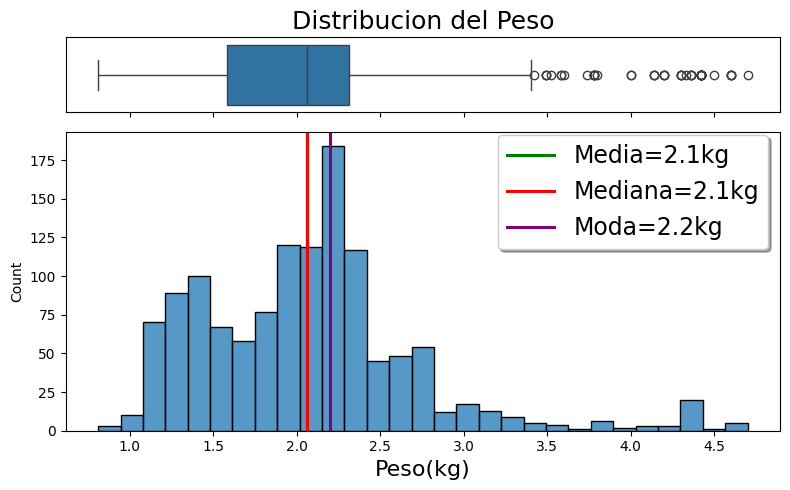

In [170]:
graficar_distribucion_numerica(df_Limpio, 'Peso(kg)', 'Distribucion del Peso','kg')

### Distribución del Precio

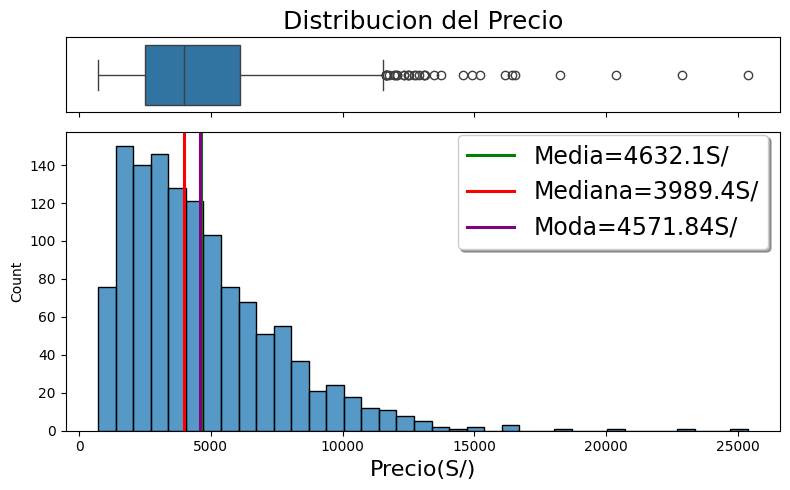

In [171]:
graficar_distribucion_numerica(df_Limpio, 'Precio(S/)', 'Distribucion del Precio','S/')

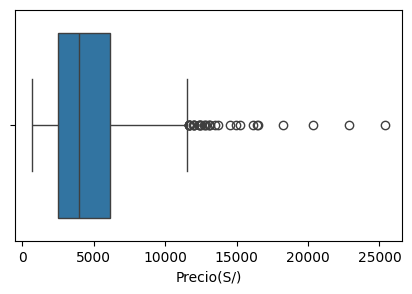

In [172]:
fig, ax  = plt.subplots(figsize=(5,3))
ax=sns.boxplot(x='Precio(S/)', data=df_Limpio)

In [173]:
df_Limpio.columns

Index(['Marca', 'Producto', 'Tipo', 'Pulgadas', 'Procesador', 'RAM(GB)', 'GPU',
       'SistemaOperativo', 'Peso(kg)', 'Precio(S/)', 'Resolucion',
       'TipoPantalla', 'PantallaTactil', 'Proc_freq(GHz)',
       'Almacenamiento_1(GB)', 'Almacenamiento_1_tipo', 'Almacenamiento_2(GB)',
       'Almacenamiento_2_tipo', 'Marca_procesador', 'Marca_GPU'],
      dtype='object')

<Axes: xlabel='Tipo', ylabel='Precio(S/)'>

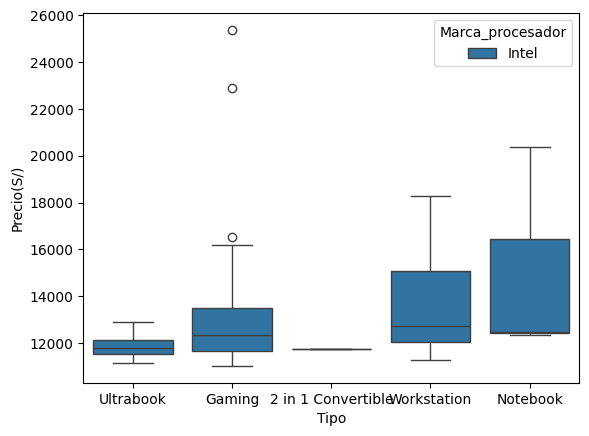

In [174]:
sns.boxplot(x='Tipo', y='Precio(S/)', data=df[df['Precio(S/)']>11000], hue='Marca_procesador')